In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Documents/Patient.csv.csv')
df.head()




,patient_id,patient_name,age,gender,city,admission_date,discharge_date,disease,department,doctor_id,bill_amount,status
0,1,Vikram Singh,18.0,Male,Hyderabad,2023-10-09,2023-10-14,Hypertension,Cardiology,7,55752.46,Discharged
1,2,Divya Menon,8.0,Female,Delhi,2023-04-06,2023-04-11,Hypertension,Cardiology,8,47093.38,Discharged
2,3,Sunita Agarwal,59.0,Male,Delhi,2023-01-07,2023-01-21,Dengue,Pediatrics,6,30518.79,Discharged
3,4,Vivek Pandey,49.0,Male,Pune,2024-01-25,NaN,Hypertension,Cardiology,8,50279.45,Admitted
4,5,NaN,51.0,Male,Mumbai,2024-01-23,NaN,Asthma,Pediatrics,4,48301.41,Admitted


In [15]:
df = pd.read_csv('Documents/doctor.csv.csv')
df.head()

,doctor_id,doctor_name,specialization,department,experience_years
0,1,Dr. Sharma,Cardiologist,Cardiology,7
1,2,Dr. Patel,Orthopedic,Orthopedics,4
2,3,Dr. Mehta,General Physician,General Medicine,16
3,4,Dr. Gupta,Neurologist,Neurology,13
4,5,Dr. Reddy,Pediatrician,Pediatrics,20


In [16]:
df = pd.read_csv('Documents/department.csv.csv')
df.head()

,department_id,department_name,total_beds,occupied_beds
0,1,Cardiology,50,38
1,2,Orthopedics,40,22
2,3,General Medicine,80,65
3,4,Neurology,30,18
4,5,Pediatrics,45,30


In [17]:
df = pd.read_csv('Documents/billing.csv.csv')
df.head()

,bill_id,patient_id,total_amount,insurance_amount,paid_amount,payment_status
0,1,1,39262.69,7117.27,34548.10,Pending
1,2,2,12999.00,2974.41,5940.41,Pending
2,3,3,57445.93,756.20,23194.32,Pending
3,4,4,5607.35,2910.44,5536.16,Paid
4,5,5,73296.27,32771.00,69362.68,Paid


In [18]:
patients = pd.read_csv('Documents/Patient.csv.csv')
doctors = pd.read_csv('Documents/doctor.csv.csv')
departments = pd.read_csv('Documents/department.csv.csv')
billing = pd.read_csv('Documents/billing.csv.csv')

print("Patients shape:", patients.shape)
print("Doctors shape:", doctors.shape)
print("Departments shape:", departments.shape)
print("Billing shape:", billing.shape)

Patients shape: (100, 12)
Doctors shape: (10, 5)
Departments shape: (5, 4)
Billing shape: (100, 6)


In [19]:
print("=== PATIENTS NULL VALUES ===")
print(patients.isnull().sum())

print("\n=== BILLING NULL VALUES ===")
print(billing.isnull().sum())

=== PATIENTS NULL VALUES ===
patient_id         0
patient_name       3
age                2
gender             0
city               0
admission_date     0
discharge_date    50
disease            0
department         0
doctor_id          0
bill_amount        3
status             0
dtype: int64

=== BILLING NULL VALUES ===
bill_id             0
patient_id          0
total_amount        0
insurance_amount    0
paid_amount         0
payment_status      0
dtype: int64


In [20]:
# Fill missing patient_name with 'Unknown'
patients['patient_name'].fillna('Unknown', inplace=True)

# Fill missing age with median age
patients['age'].fillna(patients['age'].median(), inplace=True)

# Fill missing bill_amount with median bill amount
patients['bill_amount'].fillna(patients['bill_amount'].median(), inplace=True)

# discharge_date NULLs are valid — leave them as is

print("=== NULL VALUES AFTER CLEANING ===")
print(patients.isnull().sum())

=== NULL VALUES AFTER CLEANING ===
patient_id         0
patient_name       0
age                0
gender             0
city               0
admission_date     0
discharge_date    50
disease            0
department         0
doctor_id          0
bill_amount        0
status             0
dtype: int64


C:\Users\SAI VARDHAN\AppData\Local\Temp\ipykernel_12408\3697063839.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patients['patient_name'].fillna('Unknown', inplace=True)
C:\Users\SAI VARDHAN\AppData\Local\Temp\ipykernel_12408\3697063839.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [21]:
# Modern pandas syntax — no warnings
patients = patients.fillna({
    'patient_name': 'Unknown',
    'age': patients['age'].median(),
    'bill_amount': patients['bill_amount'].median()
})

print("Cleaned successfully!")

Cleaned successfully!


In [22]:
print("Duplicate rows in patients:", patients.duplicated().sum())
print("Duplicate rows in billing:", billing.duplicated().sum())

Duplicate rows in patients: 0
Duplicate rows in billing: 0


In [23]:
print("=== PATIENTS BASIC INFO ===")
print(patients.describe())

=== PATIENTS BASIC INFO ===
       patient_id        age   doctor_id   bill_amount
count  100.000000  100.00000  100.000000    100.000000
mean    50.500000   43.77000    5.960000  41989.916300
std     29.011492   22.35203    2.741083  20348.407822
min      1.000000    5.00000    1.000000   5586.730000
25%     25.750000   23.25000    4.000000  23814.512500
50%     50.500000   46.00000    7.000000  41344.780000
75%     75.250000   61.00000    8.000000  58002.235000
max    100.000000   80.00000   10.000000  78795.200000


C:\Users\SAI VARDHAN\AppData\Local\Temp\ipykernel_12408\2998887457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='Blues_d')


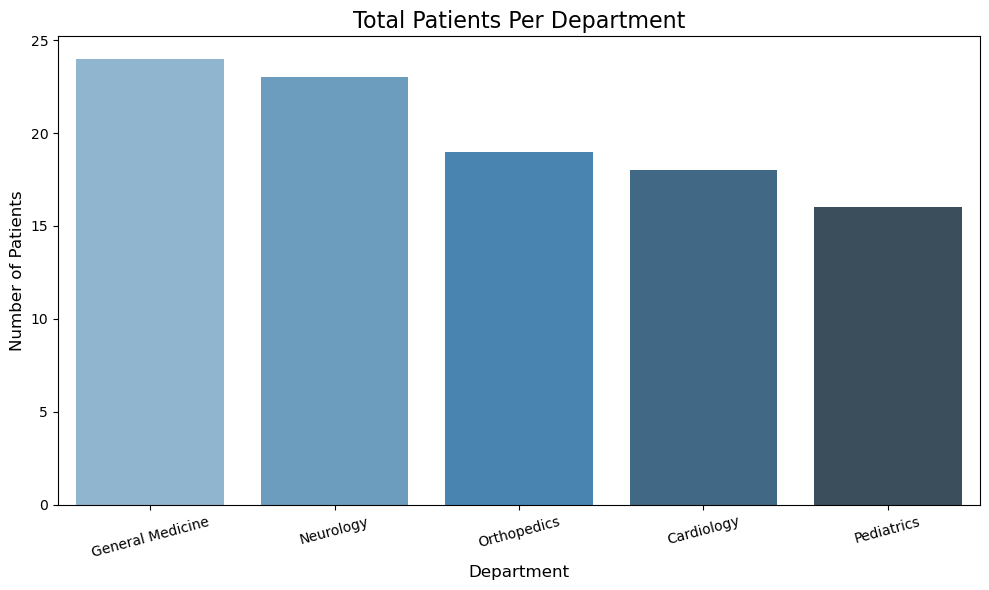

In [24]:
plt.figure(figsize=(10, 6))
dept_counts = patients['department'].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='Blues_d')
plt.title('Total Patients Per Department', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

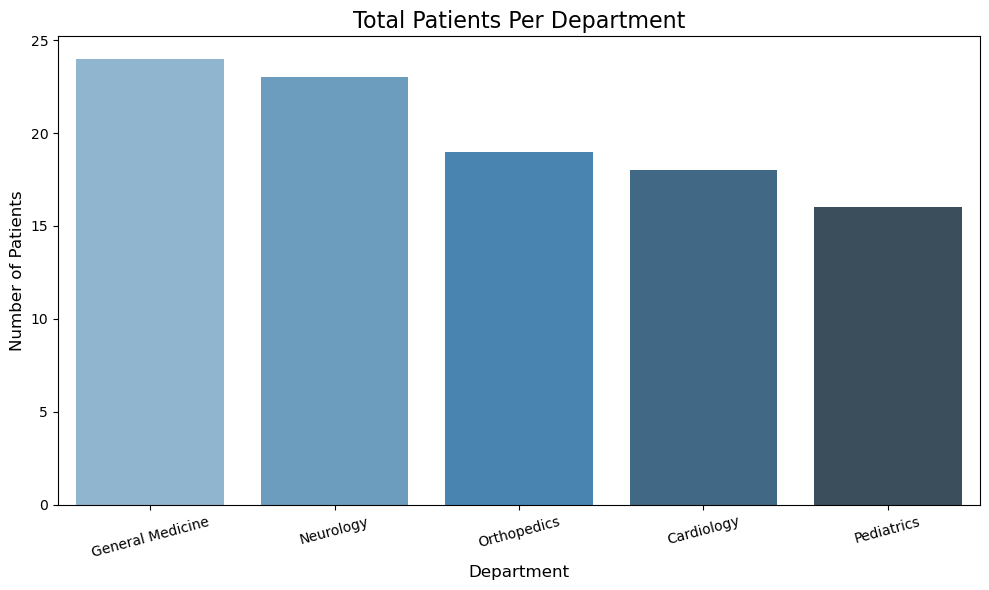

In [26]:
plt.figure(figsize=(10, 6))
dept_counts = patients['department'].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, 
            hue=dept_counts.index, palette='Blues_d', legend=False)
plt.title('Total Patients Per Department', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

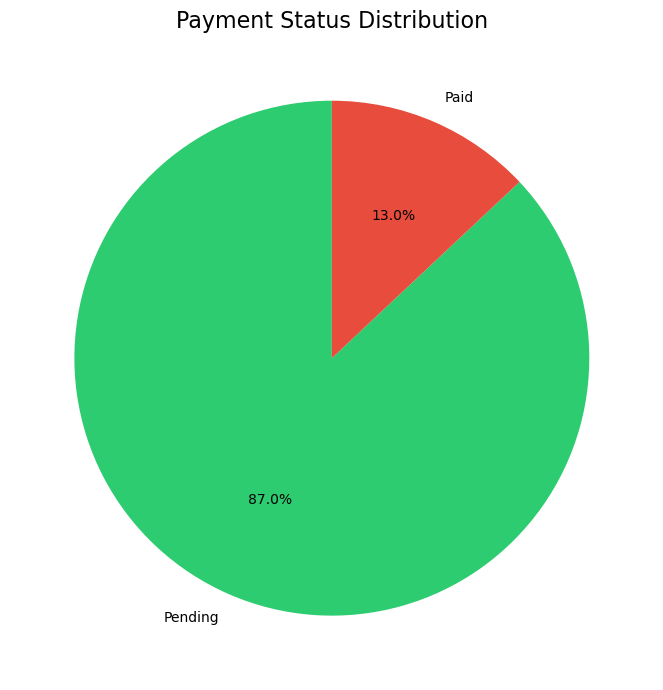

In [27]:
plt.figure(figsize=(7, 7))
payment_counts = billing['payment_status'].value_counts()
plt.pie(payment_counts.values, 
        labels=payment_counts.index, 
        autopct='%1.1f%%',
        colors=['#2ECC71', '#E74C3C'],
        startangle=90)
plt.title('Payment Status Distribution', fontsize=16)
plt.tight_layout()
plt.show()

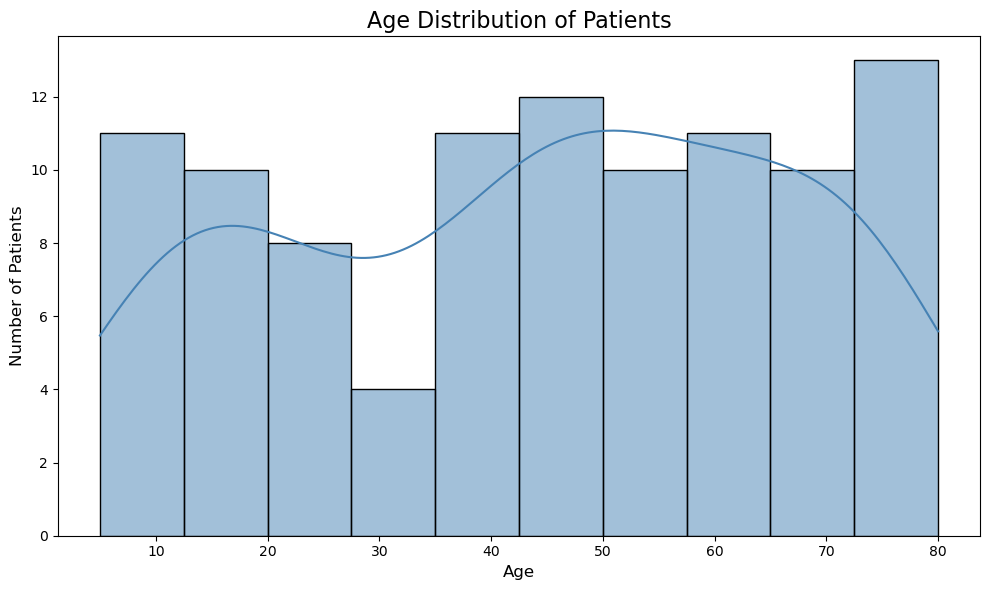

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(patients['age'], bins=10, color='steelblue', kde=True)
plt.title('Age Distribution of Patients', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.show()

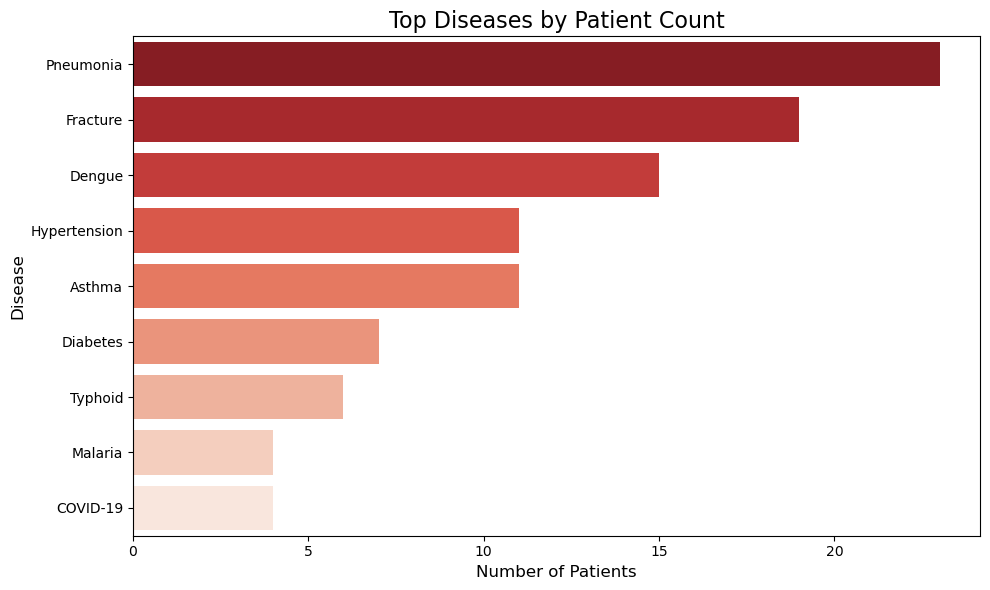

In [29]:
plt.figure(figsize=(10, 6))
disease_counts = patients['disease'].value_counts()
sns.barplot(x=disease_counts.values, y=disease_counts.index,
            hue=disease_counts.index, palette='Reds_r', legend=False)
plt.title('Top Diseases by Patient Count', fontsize=16)
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Disease', fontsize=12)
plt.tight_layout()
plt.show()